# Train Phase 2 Deep Model (Colab)

## 0. Configuration

In [4]:
from pathlib import Path

EPOCHS = 60
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
HIDDEN_DIMS = (128, 64)
BOTTLENECK = 32

MAX_TOTAL_ROWS = 1_200_000
MAX_BENIGN_FRACTION = 0.70
MAX_BENIGN_TRAIN_ROWS = 700_000
CHUNK_ROWS = 100_000
HELD_OUT_FAMILY = "Heartbleed"
SEED = 42

DRIVE_MY = Path('/content/drive/MyDrive')
CIC_CSV_FOLDER = 'cic_ids_data'

try:
    import google.colab  # noqa: F401
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False

## 0b. Mount Google Drive

In [5]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running in Colab, skipping Drive mount.')


Mounted at /content/drive


In [6]:
import sys
import subprocess
from pathlib import Path

if RUNNING_IN_COLAB:
    DATA_DIR = (DRIVE_MY / CIC_CSV_FOLDER).resolve()
    OUT_DIR = (DRIVE_MY / 'cic_ids_outputs' / 'phase2_dl').resolve()
else:
    base = Path.cwd().resolve()
    DATA_DIR = (base / 'data' / 'cic_ids').resolve()
    OUT_DIR = (base / 'models' / 'phase2_dl').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'numpy', 'pandas', 'scikit-learn', 'matplotlib', 'torch'
])
print('DATA_DIR =', DATA_DIR)
print('OUT_DIR  =', OUT_DIR)


DATA_DIR = /content/drive/MyDrive/cic_ids_data
OUT_DIR  = /content/drive/MyDrive/cic_ids_outputs/phase2_dl


## 1. Validate CSV files

In [7]:
CIC_DAY_FILES = (
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
)

if not DATA_DIR.is_dir():
    raise FileNotFoundError(f'Missing folder: {DATA_DIR}')
missing = [n for n in CIC_DAY_FILES if not (DATA_DIR / n).is_file()]
if missing:
    raise FileNotFoundError('Missing CSV files:\n- ' + '\n- '.join(missing))
print('All required CIC-IDS files found.')

All required CIC-IDS files found.


## 2. Load data with memory-safe chunking

In [8]:
import gc
import math
import numpy as np
import pandas as pd


def norm_family(label: str) -> str:
    s = str(label).strip().replace('\x00', '')
    low = s.lower()
    if low == 'benign': return 'Benign'
    if 'heartbleed' in low: return 'Heartbleed'
    if 'web attack' in low or 'webattack' in low: return 'WebAttack'
    if 'portscan' in low: return 'PortScan'
    if 'dos' in low and 'ddos' not in low: return 'DoS'
    if 'ddos' in low: return 'DDoS'
    if 'bot' in low: return 'Bot'
    if 'infiltration' in low: return 'Infiltration'
    return s

rng = np.random.default_rng(SEED)
target_total = int(MAX_TOTAL_ROWS) if MAX_TOTAL_ROWS else None
target_benign = None if target_total is None else int(target_total * MAX_BENIGN_FRACTION)
per_file_benign = None if target_benign is None else math.ceil(target_benign / len(CIC_DAY_FILES))

benign_parts, attack_parts = [], []
for name in CIC_DAY_FILES:
    p = DATA_DIR / name
    keep_b = keep_a = 0
    for chunk in pd.read_csv(p, low_memory=True, chunksize=CHUNK_ROWS):
        chunk.columns = [c.strip() for c in chunk.columns]
        raw = chunk['Label'].astype(str).str.strip()
        y = (raw.str.lower() != 'benign').astype(np.int8)
        fam = raw.map(norm_family)
        x = chunk.drop(columns=['Label'], errors='ignore').select_dtypes(include=[np.number])
        if x.empty:
            continue
        x = x.replace([np.inf, -np.inf], np.nan).astype(np.float32, copy=False)
        x['y'] = y.values
        x['attack_family'] = fam.values

        atk = x[x['y'] == 1]
        if len(atk):
            attack_parts.append(atk.copy())
            keep_a += len(atk)

        ben = x[x['y'] == 0]
        if len(ben):
            if per_file_benign is None:
                take = ben
            else:
                rem = per_file_benign - keep_b
                if rem <= 0:
                    take = None
                else:
                    n_take = min(rem, len(ben))
                    if n_take < len(ben):
                        idx = rng.choice(len(ben), size=n_take, replace=False)
                        take = ben.iloc[idx].copy()
                    else:
                        take = ben.copy()
            if take is not None and len(take):
                benign_parts.append(take)
                keep_b += len(take)

    print(f'loaded {name}: benign={keep_b:,}, attacks={keep_a:,}')
    gc.collect()

benign_df = pd.concat(benign_parts, ignore_index=True) if benign_parts else pd.DataFrame()
attack_df = pd.concat(attack_parts, ignore_index=True) if attack_parts else pd.DataFrame()
if target_total:
    if len(attack_df) >= target_total:
        clean = attack_df.sample(n=target_total, random_state=SEED).reset_index(drop=True)
    else:
        n_ben = max(0, target_total - len(attack_df))
        if len(benign_df) > n_ben:
            benign_df = benign_df.sample(n=n_ben, random_state=SEED).reset_index(drop=True)
        clean = pd.concat([benign_df, attack_df], ignore_index=True)
else:
    clean = pd.concat([benign_df, attack_df], ignore_index=True)

clean = clean.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
feature_cols = [c for c in clean.columns if c not in {'y', 'attack_family'}]
clean[feature_cols] = clean[feature_cols].fillna(clean[feature_cols].median(numeric_only=True))
print('loaded', len(clean), 'rows and', len(feature_cols), 'numeric features')
print(clean['attack_family'].value_counts().to_string())


loaded Monday-WorkingHours.pcap_ISCX.csv: benign=105,000, attacks=0
loaded Tuesday-WorkingHours.pcap_ISCX.csv: benign=105,000, attacks=13,835
loaded Wednesday-workingHours.pcap_ISCX.csv: benign=105,000, attacks=252,672
loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: benign=105,000, attacks=2,180
loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: benign=105,000, attacks=36
loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: benign=105,000, attacks=1,966
loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: benign=105,000, attacks=158,930
loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: benign=97,718, attacks=128,027
loaded 1200000 rows and 78 numeric features
attack_family
Benign          642354
DoS             252661
PortScan        158930
DDoS            128027
FTP-Patator       7938
SSH-Patator       5897
WebAttack         2180
Bot               1966
Infiltration        36
Heartbleed          11


## 3. Split + scale

In [9]:
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

@dataclass
class Split:
    x: pd.DataFrame
    y: np.ndarray

features = [c for c in clean.columns if c not in {'y', 'attack_family'}]
benign = clean[clean['y'] == 0]
attacks = clean[clean['y'] == 1]
held = attacks[attacks['attack_family'] == HELD_OUT_FAMILY]
known = attacks[attacks['attack_family'] != HELD_OUT_FAMILY]
if len(held) == 0 and len(attacks) > 0:
    HELD_OUT_FAMILY = attacks['attack_family'].value_counts().index[0]
    held = attacks[attacks['attack_family'] == HELD_OUT_FAMILY]
    known = attacks[attacks['attack_family'] != HELD_OUT_FAMILY]

b_tr, b_tmp = train_test_split(benign, test_size=0.30, random_state=SEED)
b_val, b_te = train_test_split(b_tmp, test_size=2/3, random_state=SEED)

te_known = pd.concat([b_te, known], ignore_index=True).sample(frac=1.0, random_state=SEED)
te_zero = pd.concat([b_te, held], ignore_index=True).sample(frac=1.0, random_state=SEED)

x_train = b_tr[features].to_numpy(dtype=np.float32)
x_val = b_val[features].to_numpy(dtype=np.float32)
if MAX_BENIGN_TRAIN_ROWS and len(x_train) > MAX_BENIGN_TRAIN_ROWS:
    idx = np.random.default_rng(SEED).choice(len(x_train), size=MAX_BENIGN_TRAIN_ROWS, replace=False)
    x_train = x_train[idx]

scaler = StandardScaler().fit(x_train)
x_train_s = scaler.transform(x_train).astype(np.float32)
x_val_s = scaler.transform(x_val).astype(np.float32)

x_known_s = scaler.transform(te_known[features].to_numpy(dtype=np.float32)).astype(np.float32)
y_known = te_known['y'].to_numpy(dtype=np.int8)
x_zero_s = scaler.transform(te_zero[features].to_numpy(dtype=np.float32)).astype(np.float32)
y_zero = te_zero['y'].to_numpy(dtype=np.int8)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, 'train shape:', x_train_s.shape, 'held-out family:', HELD_OUT_FAMILY)

device: cuda train shape: (449647, 78) held-out family: Heartbleed


## 4. Train autoencoder

In [10]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

class Autoencoder(nn.Module):
    def __init__(self, n_features, hidden_dims=(128, 64), bottleneck_dim=32):
        super().__init__()
        enc, prev = [], n_features
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.ReLU(inplace=True)]
            prev = h
        enc += [nn.Linear(prev, bottleneck_dim), nn.ReLU(inplace=True)]
        self.encoder = nn.Sequential(*enc)
        dec, prev = [], bottleneck_dim
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev, h), nn.ReLU(inplace=True)]
            prev = h
        dec += [nn.Linear(prev, n_features)]
        self.decoder = nn.Sequential(*dec)
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder(x_train_s.shape[1], HIDDEN_DIMS, BOTTLENECK).to(DEVICE)
loader_tr = DataLoader(TensorDataset(torch.from_numpy(x_train_s)), batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(TensorDataset(torch.from_numpy(x_val_s)), batch_size=BATCH_SIZE)
opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()

train_losses, val_losses = [], []
best_val = float('inf')
best_state = None
best_epoch = 0

for ep in range(1, EPOCHS + 1):
    model.train(); tr_tot = tr_n = 0
    for (xb,) in loader_tr:
        xb = xb.to(DEVICE)
        loss = loss_fn(model(xb), xb)
        opt.zero_grad(); loss.backward(); opt.step()
        tr_tot += float(loss.detach()) * xb.size(0); tr_n += xb.size(0)
    tr = tr_tot / max(tr_n, 1)

    model.eval(); va_tot = va_n = 0
    with torch.no_grad():
        for (xb,) in loader_val:
            xb = xb.to(DEVICE)
            va_tot += float(loss_fn(model(xb), xb)) * xb.size(0)
            va_n += xb.size(0)
    va = va_tot / max(va_n, 1)

    train_losses.append(tr); val_losses.append(va)
    if va < best_val:
        best_val = va; best_epoch = ep
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f'epoch {ep:03d}/{EPOCHS} train={tr:.6f} val={va:.6f}')

if best_state is not None:
    model.load_state_dict(best_state)

@torch.no_grad()
def rec_err(x_np, bs=1024):
    x_np = np.ascontiguousarray(x_np, dtype=np.float32)
    out = np.empty(x_np.shape[0], dtype=np.float32)
    for i in range(0, len(x_np), bs):
        xb = torch.from_numpy(x_np[i:i+bs]).to(DEVICE)
        rr = model(xb)
        out[i:i+len(xb)] = ((rr - xb) ** 2).mean(dim=1).cpu().numpy()
    return out

val_err = rec_err(x_val_s)
thr = float(np.quantile(val_err, 0.99))
known_err = rec_err(x_known_s)
zero_err = rec_err(x_zero_s)

pred_k = (known_err >= thr).astype(np.int8)
pred_z = (zero_err >= thr).astype(np.int8)
print('best epoch:', best_epoch, 'best val MSE:', best_val)
print('test_known AUC:', round(float(roc_auc_score(y_known, known_err)), 4),
      'P/R/F1:', round(float(precision_score(y_known, pred_k, zero_division=0)),4),
      round(float(recall_score(y_known, pred_k, zero_division=0)),4),
      round(float(f1_score(y_known, pred_k, zero_division=0)),4))
print('test_zero AUC :', round(float(roc_auc_score(y_zero, zero_err)), 4),
      'P/R/F1:', round(float(precision_score(y_zero, pred_z, zero_division=0)),4),
      round(float(recall_score(y_zero, pred_z, zero_division=0)),4),
      round(float(f1_score(y_zero, pred_z, zero_division=0)),4))

epoch 001/60 train=0.241339 val=0.206278
epoch 002/60 train=0.158701 val=0.118766
epoch 003/60 train=0.090122 val=0.168222
epoch 004/60 train=0.106118 val=0.059771
epoch 005/60 train=0.075640 val=0.059049
epoch 006/60 train=0.074099 val=0.069840
epoch 007/60 train=0.100496 val=0.080199
epoch 008/60 train=0.071391 val=0.095656
epoch 009/60 train=0.069769 val=0.064714
epoch 010/60 train=0.065542 val=0.031997
epoch 011/60 train=0.061127 val=0.056338
epoch 012/60 train=0.064036 val=0.041157
epoch 013/60 train=0.055257 val=0.053034
epoch 014/60 train=0.050157 val=0.052964
epoch 015/60 train=0.043086 val=0.052882
epoch 016/60 train=0.042276 val=0.111407
epoch 017/60 train=0.038719 val=0.027920
epoch 018/60 train=0.035102 val=0.055314
epoch 019/60 train=0.047257 val=0.063542
epoch 020/60 train=0.034965 val=0.052690
epoch 021/60 train=0.046165 val=0.052423
epoch 022/60 train=0.035647 val=0.056973
epoch 023/60 train=0.032196 val=0.126244
epoch 024/60 train=0.074054 val=0.034462
epoch 025/60 tra

## 5. Training curves

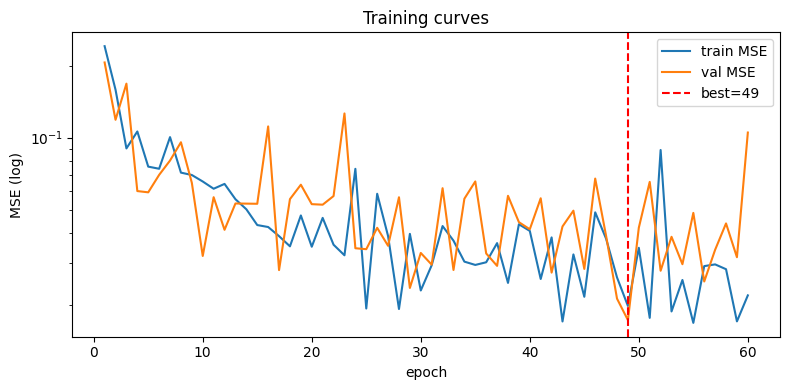

In [11]:
import matplotlib.pyplot as plt

ep = np.arange(1, len(train_losses) + 1)
plt.figure(figsize=(8, 4))
plt.plot(ep, train_losses, label='train MSE')
plt.plot(ep, val_losses, label='val MSE')
plt.axvline(best_epoch, color='red', linestyle='--', label=f'best={best_epoch}')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE (log)')
plt.title('Training curves')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Save model artifact (`ft_ae.pth`)

In [12]:
import json

ckpt = OUT_DIR / 'ft_ae.pth'
torch.save({
    'config': {
        'n_features': int(x_train_s.shape[1]),
        'hidden_dims': list(HIDDEN_DIMS),
        'bottleneck_dim': int(BOTTLENECK),
    },
    'state_dict': model.state_dict(),
    'scaler': {
        'mean': np.asarray(scaler.mean_, dtype=np.float32),
        'scale': np.asarray(scaler.scale_, dtype=np.float32),
    },
    'threshold': float(thr),
    'feature_names': list(features),
    'extra': {
        'held_out_family': HELD_OUT_FAMILY,
        'epochs_run': len(train_losses),
        'best_epoch': best_epoch,
    },
}, str(ckpt))

(OUT_DIR / 'history.json').write_text(json.dumps({
    'train_loss': train_losses,
    'val_loss': val_losses,
    'best_epoch': best_epoch,
    'threshold': float(thr),
}, indent=2))

print('Saved model:', ckpt)
print('Saved history:', OUT_DIR / 'history.json')

Saved model: /content/drive/MyDrive/cic_ids_outputs/phase2_dl/ft_ae.pth
Saved history: /content/drive/MyDrive/cic_ids_outputs/phase2_dl/history.json
